practict

In [11]:
fs = pd.read_pickle(f".\\broker\\broker_sell_{'1020'}.pkl")
fs

,券商名稱,買進張數,賣出張數,差額,stockid,mainBroker,subBroker,date
0,00881國泰台灣5G+,8,511,-503,,1020,1020,2022-03-01
0,國光生,0,326,-326,4142,1020,102C,2023-02-09
0,鈺德,0,180,-180,3050,1020,1022,2023-02-17
0,十銓,0,165,-165,4967,1020,102C,2023-02-16
0,華航,19,325,-306,2610,1020,1025,2023-02-16
...,...,...,...,...,...,...,...,...
11399,00830國泰費城半導體,0,8,-8,,1020,1023,2023-02-08
11399,台表科,0,3,-3,6278,1020,1025,2023-02-08
11399,00690兆豐藍籌30,0,10,-10,,1020,1021,2023-02-08
11399,啟��,0,20,-20,6285,1020,1020,2023-02-08


In [167]:
import numpy as np
from sklearn.linear_model import LinearRegression
arr1=[1,2,3,4,5,5]
arr2=[1,2,3,4,3,1]
correlation = np.corrcoef(arr1, arr2)[0, 1]
print(correlation)

#arr1 = close[stockid]
#arr2 = close['bkdata']
a = np.array(arr2).reshape(-1,1)
b = arr1
reg = LinearRegression().fit(a,b)
b_pred = reg.predict(a)
b_pred

0.337099931231621


array([2.72727273, 3.18181818, 3.63636364, 4.09090909, 3.63636364,
       2.72727273])

In [1]:
import pandas as pd
brokerdf = pd.read_csv('broker_id1.csv')

get data from broker and merge sell and buy

In [18]:

import pandas as pd
import datetime
import gc
def merge_sell_buy_data(mid,subid,sotckid,startdate):
    cnt = 0
    fs = pd.read_pickle(f".\\broker\\broker_sell_{mid}.pkl")
    fs.sort_values('subBroker')
    if subid !='-':
        fs = fs[fs['subBroker']== subid]
    fs = fs[fs['stockid'] == sotckid]
    fs.set_index('date',inplace= True)
    fs.sort_index(inplace=True)
    fs = fs[fs.index > pd.to_datetime(startdate)]
    #-----------------------
    fs1 = pd.read_pickle(f".\\broker\\broker_buy_{mid}.pkl")
    fs1.sort_values('subBroker')
    if subid !='-':
        fs1 = fs1[fs1['subBroker']==subid]
    fs1 = fs1[fs1['stockid'] == sotckid]
    fs1.set_index('date',inplace= True)
    fs1.sort_index(inplace=True)
    fs1 = fs1[fs1.index > pd.to_datetime(startdate)]
    fs = fs.append(fs1)
    fs.sort_index(inplace=True)
    fs1 = None
    gc.collect()
    return fs
ssd = merge_sell_buy_data('1020','1020','8299',pd.to_datetime(datetime.date(2022,11,1)))
ssd

c:\Users\danson_tsui\AppData\Local\Programs\Python\Python37\lib\site-packages\pandas\core\ops\array_ops.py:73: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior.  In a future version these will be considered non-comparable.Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  result = libops.scalar_compare(x.ravel(), y, op)
c:\Users\danson_tsui\AppData\Local\Programs\Python\Python37\lib\site-packages\pandas\core\ops\array_ops.py:73: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior.  In a future version these will be considered non-comparable.Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  result = libops.scalar_compare(x.ravel(), y, op)


,券商名稱,買進張數,賣出張數,差額,stockid,mainBroker,subBroker
date,,,,,,,
2022-11-14,群聯,1,28,-27,8299,1020,1020
2022-11-16,群聯,7,79,-72,8299,1020,1020
2022-11-21,群聯,30,4,26,8299,1020,1020
2022-12-06,群聯,60,13,47,8299,1020,1020
2023-01-05,群聯,22,0,22,8299,1020,1020
2023-01-11,群聯,2,21,-19,8299,1020,1020
2023-02-09,群聯,36,0,36,8299,1020,1020
2023-02-10,群聯,39,1,38,8299,1020,1020


In [ ]:


dff = pd.DataFrame(fs)
dff.to_csv('mytemp.csv')
print(dff.head())
s= dff['差額'].cumsum()
s.head()

In [ ]:
from finlab.data import Data

data = Data()

s89 = data.get("收盤價")
df8299 = pd.DataFrame(s89)
df8299 = df8299['8299']
df8299 = pd.DataFrame(df8299)

df8299


計算all stk correlation value

In [2]:
import numpy as np
from finlab.data import Data
import gc
def get_correlation_value(brokerdata,stockid,startdate,nocumsum=False):
    data = Data()
    s89 = data.get("收盤價")
    close = pd.DataFrame(s89)
    close = close[stockid]
    close = pd.DataFrame(close)
    close = close[close.index > pd.to_datetime(startdate)]
    #dff = brokerdata #pd.DataFrame(brokerdata)
    if (nocumsum) == True:
        s= brokerdata['差額'].cumsum()
    else:
        s=brokerdata['差額']
    close['bkdata'] = s

    close['bkdata'] = close['bkdata'].ffill()
    close.fillna(0,inplace=True)
    arr1 = close[stockid]
    arr2 = close['bkdata']

    correlation = np.corrcoef(arr1, arr2)[0, 1]
    #print("Correlation:", correlation)
    cnt = len(close)
    #close = None
    s89 = None
    gc.collect()
    return correlation,close,cnt

#df8299['8299'].plot()
#(df8299['bkdata']).plot()

相關係數計算

In [62]:
import numpy as np

arr1 = [1, 2, 1, 4, 1]
arr2 = [1, 3, -6, 7, 7]

correlation = np.corrcoef(arr1, arr2)[0, 1]
print("Correlation:", correlation)


Correlation: 0.5144957554275265


In [7]:
from finlab.data import Data
#brokerdata = merge_sell_buy_data('5380','538B','8299')
#brokerdata

data = Data()
s89 = data.get("收盤價")
alldata = pd.DataFrame(s89)
p = alldata['8299'][alldata['8299'].index.max()]
p




360.5

In [ ]:
import datetime
s.sort_index(inplace=True)
a = s[s.index == pd.to_datetime(datetime.date(2022,8,12))]
a
#aa = a[a >1]
#aa




In [36]:
import gc
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

cal correlation for each broker

In [ ]:
import gc
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
#requests.packages.urllib3.disable_warnings()

brokerdf = pd.read_csv('broker_id1.csv')
brokerdf.rename(columns={'證券商名稱':'brokerName'},inplace=True)
m = brokerdf[brokerdf['MainBroder']=='Y']

allresult = []
for midx in m.index:
    subb = brokerdf[brokerdf['brokerName']==brokerdf['brokerName'][midx]]
    mainid = m['代號'][midx]
    for subbinx in subb.index:
        dd = []
        subid = subb['代號'][subbinx]
        #print(mainid+subid)
        try:
            brokerdata = merge_sell_buy_data(mainid,subid,'8299',pd.to_datetime(datetime.date(2022,3,1)))
            bcnt = len(brokerdata)
            corr,close,cnt = get_correlation_value(brokerdata,'8299',pd.to_datetime(datetime.date(2022,3,1)))
            log = f"{mainid}-{subid},corr={corr}({bcnt})"
            dd.append(mainid)
            dd.append(subid)
            dd.append(corr)
            dd.append(bcnt)
            allresult.append(dd)
            print(log)
            gc.collect()
        except Exception as e:
            continue
        #break
    #break

cols = ['id','sid','corr','bktimes']
predict_df = pd.DataFrame(data = allresult,columns=cols)
predict_df.to_csv('pdata.csv')

start simulation broker 7750

In [39]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plot
mainid = '1020'
subid = '-'
stockid='8299'
#,'8299',pd.to_datetime(datetime.date(2022,11,1))
brokerdata = merge_sell_buy_data(mainid,subid,stockid,pd.to_datetime(datetime.date(2022,3,1)))
s = brokerdata.groupby('date')['差額'].sum()
df = pd.DataFrame(data=s,columns=['差額'])
#corr,cnt = get_correlation_value(brokerdata,'8299')
#計算正相關係數
corr,close,cnt = get_correlation_value(df,stockid,pd.to_datetime(datetime.date(2022,3,1)),True)
print(corr)

close.to_csv(f'pdata1_{stockid}_t.csv')

brokerdata = merge_sell_buy_data(mainid,subid,stockid,pd.to_datetime(datetime.date(2022,3,1)))
s = brokerdata.groupby('date')['差額'].sum()
df = pd.DataFrame(data=s,columns=['差額'])
#corr,cnt = get_correlation_value(brokerdata,'8299')
#計算正相關係數
corr,close,cnt = get_correlation_value(df,stockid,pd.to_datetime(datetime.date(2022,3,1)),False)
print(corr)
close.to_csv(f'pdata1_{stockid}_f.csv')

print(len(close))


0.6091883986922109
-0.229800006229372
239


In [42]:
#sss = brokerdata.groupby(by=['Index']).sum()
s1 = brokerdata.groupby('date')['差額'].sum()
df = pd.DataFrame(data=s1,columns=['差額'])
df




,差額
date,
2022-03-03,30
2022-03-08,-33
2022-03-09,-72
2022-03-31,-11
2022-04-11,-34
...,...
2023-02-02,-47
2023-02-09,36
2023-02-10,38


計算回歸分析 並填入pred欄位

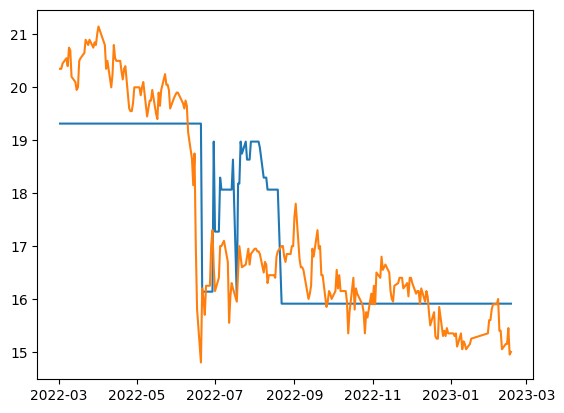

In [7]:


arr1 = close[stockid]
arr2 = close['bkdata']
a = np.array(arr2).reshape(-1,1)
b = arr1
reg = LinearRegression().fit(a,b)
b_pred = reg.predict(a)
#print(b_pred)'
close['pred'] = b_pred
plot.plot(close['pred'])
close.to_csv('psotck1.csv')
#plot.plot(close['8299'])
s1 = close[stockid]
#s1.reset_index(drop=True,inplace=True)

s2 = s1[s1 != 0]
plot.plot(s2)
#close.to_csv('pdata1.csv')

transation condition 1: pred是否有變化 - pred 前後有差值代表有變化 , 轉化成0,1 [p_shift_diff]

In [86]:
close['bs'] = 0
pshift =  close['pred'].shift(1)
close['p_shift_diff'] =  close['pred']  - pshift
close['p_shift_diff'].fillna(0,inplace=True)
#close['p_shift_diff'] = close['p_shift_diff'].astype(np.int8)
s= (close['p_shift_diff'] != 0)
hold = pd.DataFrame(np.nan, index=close.index, columns=['t'])
hold[s] = 1
hold.fillna(0,inplace=True)
close['p_shift_diff']  = hold
close['p_shift_diff'] = close['p_shift_diff'].astype(np.int8)
close.head(2)


,3017,bkdata,pred,bs,p_shift_diff
date,,,,,
2022-03-02,108.5,0.0,108.158367,0,0
2022-03-03,112.0,0.0,108.158367,0,0


transation condition 2: pred跟stk price 是否有差異 - pred - close

In [87]:
close['p_stk_diff'] = close['pred'] -  close[stockid]
close['hold'] = np.nan
#close['trans_price'] = 0
close.head(5)

,3017,bkdata,pred,bs,p_shift_diff,p_stk_diff,hold
date,,,,,,,
2022-03-02,108.5,0.0,108.158367,0,0,-0.341633,NaN
2022-03-03,112.0,0.0,108.158367,0,0,-3.841633,NaN
2022-03-04,113.0,0.0,108.158367,0,0,-4.841633,NaN
2022-03-07,105.5,-10.0,109.051715,0,1,3.551715,NaN
2022-03-08,105.5,23.0,106.103668,0,1,0.603668,NaN


transation case 1
if 條件1 == 1 and hold == 0 then do b or s
不考慮pred and close是否維持同樣方向

In [89]:
def case1_trans(close,stockid):
    trans = 0
    price = 0
    close['hold'] = np.nan
    close['trans'] = 0
    close['hold_price'] =0
    close['bs'] = np.nan
    for idx  in close.index:
        #bs = buy or sell direction , compare writh predit and current price 
        if close['pred'][idx] >  close[stockid][idx]:
            close['bs'][idx] = 1
        else:
            close['bs'][idx] = -1
        #trans signal is 1 and no any transation
        if close['p_shift_diff'][idx] == 1 and trans == 0:
            #do transation , hold is 1
            if close['pred'][idx]  ==  close[stockid][idx]:
                continue
            trans = 1
            close['hold'][idx] = 1
            close['trans'][idx] = 1
            price = close[stockid][idx]
        #trans signal is 1 and had transation, set close signal (hold is -1)
        elif close['p_shift_diff'][idx] == 1 and trans == 1:
            trans = 0
            close['hold'][idx] = 0
            close['trans'][idx] = -1
            price = 0

    #為了要模擬交易
    #因為訊號觸發之後要隔天才能交易所以把交易訊號shift 1天
    close['hold'] = close['hold'].shift(1)
    close['bs'] = close['bs'].shift(1)
    close['trans'] = close['trans'].shift(1)
        
    c = close[close['hold'].isna() == False]
    #然後補上該天的close p
    close['hold_price'] = c[stockid]


    return close

close = case1_trans(close,stockid)


#close['hold'].ffill(inplace= True)
#close['hold_price'].ffill(inplace= True)
close.fillna(0,inplace=True)
close.to_csv('phold.csv')
close.head(5)



,3017,bkdata,pred,bs,p_shift_diff,p_stk_diff,hold,trans,hold_price
date,,,,,,,,,
2022-03-02,108.5,0.0,108.158367,0.0,0,-0.341633,0.0,0.0,0.0
2022-03-03,112.0,0.0,108.158367,-1.0,0,-3.841633,0.0,0.0,0.0
2022-03-04,113.0,0.0,108.158367,-1.0,0,-4.841633,0.0,0.0,0.0
2022-03-07,105.5,-10.0,109.051715,-1.0,1,3.551715,0.0,0.0,0.0
2022-03-08,105.5,23.0,106.103668,1.0,1,0.603668,1.0,1.0,105.5


1 cacl profit
bs check first is buy or sell
trans recod , hold is buy or sell

In [91]:
#bs = 0

#colname = 'case1profit'
#lose[colname] = 0
def caclprofit(newcolname,transcol,holdprice,close):
    profit = 0
    eprice = 0
    sprice = 0
    trans = 0
    bs=0
    try:
        for idx  in close.index:
            if close[transcol][idx] ==1: #trans signal
                #signal trigger and no any transation
                if trans != 0:
                    raise Exception(f"if signal is 1, trans must 0, idx={idx}")
                bs =  close['bs'][idx]
                sprice = close[holdprice][idx]
                if bs == -1: #buy or sell
                    trans = -1 #記錄手上是buy or sell
                else:
                    trans = 1
            elif close[transcol][idx] ==-1: #trans signal
                eprice = close[holdprice][idx]
                if trans == -1 : #手上是buy or sell 決定profit的計算
                    close[newcolname][idx] = sprice-eprice
                    profit += sprice-eprice
                else:
                    close[newcolname][idx] = eprice-sprice
                    profit += eprice-sprice
                trans = 0
        print(str(profit))
        return close
        
        
    except Exception as e:
        print(str(e))
close['case1profit'] = 0
close = caclprofit('case1profit','trans','hold_price',close)
close.to_csv('phold.csv')    
close.head(3)


83.39999999999999


,3017,bkdata,pred,bs,p_shift_diff,p_stk_diff,hold,trans,hold_price,case1profit
date,,,,,,,,,,
2022-03-02,108.5,0.0,108.158367,0.0,0,-0.341633,0.0,0.0,0.0,0
2022-03-03,112.0,0.0,108.158367,-1.0,0,-3.841633,0.0,0.0,0.0,0
2022-03-04,113.0,0.0,108.158367,-1.0,0,-4.841633,0.0,0.0,0.0,0


transation case 2
if 條件1 == 1 and hold == 0 then do b or s
考慮pred and close是否維持同樣方向 如果是同方向 而且價格還沒到 就持續持有

In [92]:
def case2_trans(close,stockid):
    trans = 0
    trans_bs = 0
    price = 0
    #close = close.reset_index(drop=True,inplace=True)
    #close['hold2'].fillna(0,inplace=True)
    close['hold2'] = 0.0
    close['trans2'] = 0
    close['hold_price2'] =0
    close['bs'] = 0
    #close.reset_index(drop=True,inplace=True)
    sindx = close.index
    for id  in range(0,len(sindx)):
        idx = sindx[id]
    #for idx  in close.index:
        #bs = buy or sell direction , compare writh predit and current price 
        if close['pred'][idx] >  close[stockid][idx]:
            close['bs'][idx] = 1
        else:
            close['bs'][idx] = -1
        #trans signal is 1 and no any transation
        if close['p_shift_diff'][idx] == 1 and trans == 0:
            #do transation , hold is 1
            if close['pred'][idx]  ==  close[stockid][idx]:
                continue
            trans = 1
            idxn = sindx[id+1]
            trans_bs = close['bs'][idx] 
            close['hold2'][idxn] = 1
            close['trans2'][idxn] = 1
            price = close[stockid][idxn]
            close['hold_price2'][idxn]=price
        #if trans ==1 (buy Strategy) and current price is more then preditc price then close
        elif trans == 1 and (trans_bs==1 and close[stockid][idx] >= close['pred'][idx]):
            if close['trans2'][idx] != 0:
                continue
            trans = 0
            close['hold2'][idx] = 0
            close['trans2'][idx] = -1
            price = close[stockid][idx]
            close['hold_price2'][idx]=price
        #if trans ==-1 (sell Strategy) and current price is lenn then preditc price then close            
        elif trans == 1 and (trans_bs==-1 and close[stockid][idx] <= close['pred'][idx]):
            if close['trans2'][idx] != 0:
                continue
            trans = 0
            close['hold2'][idx] = 0
            close['trans2'][idx] = -1
            price = close[stockid][idx]
            close['hold_price2'][idx]=price
        #if have trans signa and 相反 direction
        elif close['p_shift_diff'][idx] == 1 and trans == 1:
            if close['bs'][idx] != trans_bs:
                #force close hold
                close['hold2'][idx] = 0
                idxn = sindx[id+1]
                close['trans2'][idxn] = -1
                price = close[stockid][idxn]
                close['hold_price2'][idxn]=price
                trans = 0


    #為了要模擬交易
    #因為訊號觸發之後要隔天才能交易所以把交易訊號shift 1天
    #close['hold2'] = close['hold2'].shift(1)
    close['bs'] = close['bs'].shift(1)
    #close['trans2'] = close['trans2'].shift(1)
        
    c = close[close['hold2'].isna() == False]
    #然後補上該天的close p
    #close['hold_price2'] = c['8299']


    return close

close = case2_trans(close,stockid)
#close['hold'].ffill(inplace= True)
#close['hold_price'].ffill(inplace= True)
close.fillna(0,inplace=True)
close.head(30)

close.to_csv('phold.csv')

colname = 'case2profit'
close[colname] = 0
close = caclprofit(colname,'trans2','hold_price2',close)
close.to_csv('phold.csv')    


142


transation case3 , 依據case2 可以把最高最低價也納入
not doing

In [71]:
df = pd.read_csv('broker_id2.csv',encoding='big5',errors='ignore')
df['valid'] = 'Y'
#del df['Unnamed: 0']
df.to_csv('broker_id2.csv',index=False,encoding='big5',errors='ignore')

In [74]:
df = pd.read_csv('broker_id2.csv',encoding='big5')


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa5 in position 0: invalid start byte

In [140]:
import matplotlib.pyplot as plt
s1 = close[['3034','bs','trans2','hold_price2']]
s1.head(2)

#fig = plt.figure(figsize = (10, 8),dpi=80)


#lt.annotate('test',xy=(5,100),xytext=(5,100), size=50)
#plt.text(300,100,"test",fontsize=15,verticalalignment="top",horizontalalignment="right")
#plt.plot(s1['3017'])
#plt.show()


,3017,bs,trans2,hold_price2
date,,,,
2022-03-02,108.5,0.0,0,0
2022-03-03,112.0,-1.0,0,0


In [127]:
s1.head(2)

,3017,bs,trans2,hold_price2
date,,,,
2022-03-02,108.5,0.0,0,0
2022-03-03,112.0,-1.0,0,0


In [ ]:
畫bs chart

In [169]:
import matplotlib.pyplot as plt
def bs_chart(S1,stockid):
    fig = plt.figure(figsize = (10, 8),dpi=80)
    s1 = s1.reset_index()
    usesz = pd.to_numeric(s1[stockid])
    useszstr = []
    pretrans=''
    for idx in s1.index:
        if s1['bs'][idx] == -1 and s1['trans2'][idx]==1:
            useszstr.append('s')
            pretrans = 's'
        elif s1['bs'][idx] == 1 and s1['trans2'][idx]==1:
            useszstr.append('b')
            pretrans = 'b'
        elif s1['trans2'][idx]==-1:
            if pretrans == 's':
                useszstr.append('b')
            else:
                useszstr.append('s')
        else:
                useszstr.append('')


        #xtickss = s1['']
        for i in usesz.index:
            plt.annotate(useszstr[i],xy=(i,usesz[i]),xytext=(i,usesz[i]), size=14)
            #xtickss.append(df1['date'][i])

        #plt.plot(s1.index,usesz,color='r',marker='.',linestyle=".",markersize=5,linewidth=1)
        plt.plot(s1.index,usesz,color='r',marker='o',linestyle="-",markersize=2,linewidth=1)
        #plt.xticks(usesz.index, xtickss,rotation = 60)


s1 = close[['3017','bs','trans2','hold_price2']]
s1.head(2)        

KeyError: "['bs', 'trans2', 'hold_price2'] not in index"

In [40]:
data = Data()
s89 = data.get("收盤價")
close = pd.DataFrame(s89)
close.tail()

stock_id,0050,0051,0052,0053,0054,0055,0056,0057,0061,1101,...,9944,9945,9946,9949,9950,9951,9955,9958,9960,9962
date,,,,,,,,,,,,,,,,,,,,,
2023-02-14,121.65,55.40,107.85,59.75,NaN,22.54,27.13,88.35,19.69,37.25,...,20.50,44.25,11.95,20.75,11.65,67.4,20.75,99.0,25.9,19.80
2023-02-15,118.85,54.85,105.05,58.30,NaN,22.41,27.05,86.50,19.65,37.55,...,20.55,44.00,11.95,20.65,11.50,67.5,20.80,100.0,25.8,19.80
2023-02-16,120.30,55.70,106.45,59.15,NaN,22.55,27.33,87.10,19.86,37.50,...,20.45,44.10,11.90,20.55,NaN,68.0,20.75,99.0,26.1,20.20
2023-02-17,118.75,55.50,104.90,58.45,NaN,22.56,27.24,86.55,19.51,38.00,...,20.50,44.10,11.85,20.50,11.70,68.1,20.65,102.5,26.4,20.15
2023-02-20,119.00,56.05,104.90,58.70,NaN,22.74,27.41,86.85,19.53,38.25,...,20.55,44.40,12.00,20.70,12.10,69.2,20.95,106.5,26.5,20.60


In [170]:
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import numpy as np
from datetime import datetime
import time
import gc
from datetime import date, timedelta

session = requests.Session()
retry = Retry(connect=3, backoff_factor=0.5)
adapter = HTTPAdapter(max_retries=retry)
session.mount('http://', adapter)
session.mount('https://', adapter)
#
#Mborkerid = '1160'
#subborkerid = '1160'
#datestr = '2022-08-12'

url = f'https://fubon-ebrokerdj.fbs.com.tw/z/zg/zgb/zgb0.djhtm?a=1020&b=1020&c=E&e=2023-02-17&f=2023-02-17'

r = session.get(url,verify= False)



In [59]:

mainid = '9800'
subid = '9800'
stockid= '2354'

hs = pd.read_csv(f"./analysis/phold_{mainid}_{subid}_{stockid}.csv")


hs['date'] = pd.to_datetime(hs['date'])


hs.set_index('date',inplace=True)
hs.index.day




FileNotFoundError: [Errno 2] No such file or directory: './analysis/phold_9800_9800_2354.csv'

In [8]:
 import pandas as pd
 fullsell = pd.read_pickle(f'.\\broker\\broker_sell_1030.pkl')
 fullsell

UnpicklingError: invalid load key, '*'.

In [17]:
import pickle
filename = '.\\broker\\broker_sell_1030.pkl'
with open(filename, 'rb') as f:
    classification_dict = pickle.loads(f.read())

UnpicklingError: invalid load key, '*'.

In [16]:
import gzip

with gzip.open(filename, 'rb') as f:
    data = pickle.loads(f.read())

OSError: Not a gzipped file (b'\x80\x04')

In [6]:
open(filename, 'a').close()
scores = {};
try:
    with open(filename, "rb") as file:
        unpickler = pickle.Unpickler(file);
        scores = unpickler.load();
        if not isinstance(scores, dict):
            scores = {};
except EOFError:
    print("eof")

eof


In [ ]:
classification_dict